In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 130, 'font.family': 'DejaVu Sans',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titlesize': 12, 'axes.titleweight': 'bold',
    'axes.labelsize': 10, 'xtick.labelsize': 8.5, 'ytick.labelsize': 8.5,
    'legend.fontsize': 8.5, 'figure.facecolor': 'white',
    'axes.facecolor': '#f8f8f6', 'axes.grid': True,
    'grid.color': 'white', 'grid.linewidth': 0.8,
})

## 1 — Load & Parse Data

In [3]:
from pathlib import Path


CSV_PATH = Path("/scratch/umni5/a/li5125/DOE_analysis/RFI-Rider_flexibility_index-/bjcta_para.csv")
df_raw = pd.read_csv(CSV_PATH)

status_clean = df_raw['Trip Status'].astype('string').str.strip().str.lower()
trip_dates = pd.to_datetime(df_raw['Trip Date'], errors='coerce')
purpose_types = sorted(df_raw['Purpose'].dropna().astype(str).unique())

completed_trips = status_clean.isin(['comp', 'completed']).sum()
cancelled_trips = status_clean.isin(['cancel', 'canceled', 'cancelled']).sum()
noshow_trips = status_clean.isin(['noshow', 'no show', 'no-show']).sum()

print(f"Total trips: {len(df_raw):,}")
print(f"Completed trips: {completed_trips:,}")
print(f"Cancelled trips: {cancelled_trips:,}")
print(f"No-show trips: {noshow_trips:,}")
print(f"Unique customers: {df_raw['Customer Number'].nunique():,}")
print(f"Purpose types ({len(purpose_types)}): {purpose_types}")
print(f"Trip date range: {trip_dates.min().date()} to {trip_dates.max().date()}")
print(f"Columns:  {list(df_raw.columns)}")
df_raw.head(3)

Total trips: 165,891
Completed trips: 91,414
Cancelled trips: 63,968
No-show trips: 10,509
Unique customers: 1,432
Purpose types (6): ['Dialysis', 'General', 'Medical', 'Other', 'School', 'Work']
Trip date range: 2022-06-01 to 2023-02-28
Columns:  ['Customer Number', 'Trip ID', 'Trip Date', 'Trip Status', 'Cancel Agent', 'Cancel Time', 'Cancel Type', 'Earliest Pick-up', 'Latest Drop-off Time', 'Requested Drop-off Time', 'Run ID', 'Latest Pick-up Time', 'Scheduled Pick-up Arrival Time', 'Pick-up Street', 'Pick-up Street Number', 'Pick-up Zipcode', 'Drop-off Street', 'Drop-off Street Number', 'Drop-off Zipcode', 'Purpose', 'pickup_address', 'dropoff_address', 'pickup_lat', 'pickup_lon', 'dropoff_lat', 'dropoff_lon', 'idx']


,Customer Number,Trip ID,Trip Date,Trip Status,Cancel Agent,Cancel Time,Cancel Type,Earliest Pick-up,Latest Drop-off Time,Requested Drop-off Time,...,Drop-off Street Number,Drop-off Zipcode,Purpose,pickup_address,dropoff_address,pickup_lat,pickup_lon,dropoff_lat,dropoff_lon,idx
0,5294,350962,6/1/22,comp,NaN,NaN,NaN,4:11,4:55,5:00,...,3201,35222.0,Dialysis,"3110 44th Ave N, 35207","3201 3rd Ave S, 35222",33.568256,-86.806758,33.517799,-86.786011,0
1,3321,346579,6/1/22,comp,NaN,NaN,NaN,4:12,4:55,5:00,...,728,35233.0,Dialysis,"6905 65th St S, 35212","728 Richard Arrington Jr Blvd S, 35233",33.542780,-86.731495,33.506276,-86.798409,1
2,5906,350156,6/1/22,comp,NaN,NaN,NaN,4:16,4:55,5:00,...,3201,35222.0,Dialysis,"204 59th St S, 35212","3201 3rd Ave S, 35222",33.541387,-86.747910,33.517799,-86.786011,2


In [6]:
purpose_completion_rate = (
    df_raw.assign(status_clean=status_clean)
    .dropna(subset=['Purpose'])
    .groupby('Purpose')
    .agg(
        total_trips=('Trip ID', 'count'),
        completed_trips=('status_clean', lambda s: s.isin(['comp', 'completed']).sum()),
        cancelled_trips=('status_clean', lambda s: s.isin(['cancel', 'canceled', 'cancelled']).sum()),
        noshow_trips=('status_clean', lambda s: s.isin(['noshow', 'no show', 'no-show']).sum()),
    )
)

purpose_completion_rate['completed_rate'] = (
    purpose_completion_rate['completed_trips'] / purpose_completion_rate['total_trips']
)
purpose_completion_rate = purpose_completion_rate.sort_values('completed_rate', ascending=False)

display(purpose_completion_rate.style.format({
    'total_trips': '{:,.0f}',
    'completed_trips': '{:,.0f}',
    'cancelled_trips': '{:,.0f}',
    'noshow_trips': '{:,.0f}',
    'completed_rate': '{:.2%}',
}))


,total_trips,completed_trips,cancelled_trips,noshow_trips,completed_rate
Purpose,,,,,
School,"14,474","9,760","4,082",632,67.43%
Work,"46,350","29,186","14,865","2,299",62.97%
Dialysis,"29,251","18,131","8,455","2,665",61.98%
Other,"19,787","9,516","8,959","1,312",48.09%
General,"33,865","15,412","16,347","2,106",45.51%
Medical,"22,164","9,409","11,260","1,495",42.45%


More flexible purposes may have higher cancellation/adjustment behavior,
while obligatory trips are more regular and less flexible.

# 2. Filter dataset

In [7]:
keep_cols = [
    'Customer Number', 'Trip ID', 'Trip Date', 'Trip Status',
    'Earliest Pick-up', 'Latest Drop-off Time',
    'Pick-up Street', 'Pick-up Street Number', 'Pick-up Zipcode',
    'Drop-off Street', 'Drop-off Street Number', 'Drop-off Zipcode',
    'Purpose', 'pickup_address', 'dropoff_address',
    'pickup_lat', 'pickup_lon', 'dropoff_lat', 'dropoff_lon',
]

df_clean = df_raw[keep_cols].copy()
df_clean = df_clean[df_clean['Trip Status'].astype('string').str.strip().str.lower().isin(['comp', 'completed'])]
df_clean = df_clean.dropna(subset=keep_cols).copy()

print(f"Completed rows after required-column NaN filtering: {len(df_clean):,}")
df_clean.head(3)


Completed rows after required-column NaN filtering: 6,857


,Customer Number,Trip ID,Trip Date,Trip Status,Earliest Pick-up,Latest Drop-off Time,Pick-up Street,Pick-up Street Number,Pick-up Zipcode,Drop-off Street,Drop-off Street Number,Drop-off Zipcode,Purpose,pickup_address,dropoff_address,pickup_lat,pickup_lon,dropoff_lat,dropoff_lon
0,5294,350962,6/1/22,comp,4:11,4:55,44th Ave N,3110,35207.0,3rd Ave S,3201,35222.0,Dialysis,"3110 44th Ave N, 35207","3201 3rd Ave S, 35222",33.568256,-86.806758,33.517799,-86.786011
1,3321,346579,6/1/22,comp,4:12,4:55,65th St S,6905,35212.0,Richard Arrington Jr Blvd S,728,35233.0,Dialysis,"6905 65th St S, 35212","728 Richard Arrington Jr Blvd S, 35233",33.542780,-86.731495,33.506276,-86.798409
2,5906,350156,6/1/22,comp,4:16,4:55,59th St S,204,35212.0,3rd Ave S,3201,35222.0,Dialysis,"204 59th St S, 35212","3201 3rd Ave S, 35222",33.541387,-86.747910,33.517799,-86.786011


# 3. Add the zone categorin.

In [8]:
CBG_PATH = Path("/scratch/umni5/a/li5125/DOE_analysis/RFI-Rider_flexibility_index-/jefferson_county_cbg_data_2021.csv")
df_cbg = pd.read_csv(CBG_PATH)

print(f"CBG rows: {len(df_cbg):,}")
print(f"CBG columns: {list(df_cbg.columns)}")
df_cbg.head(3)


CBG rows: 583
CBG columns: ['NAME', 'Total_Population', 'Median_Household_Income', 'Mean_Household_Income', 'Under_5', 'Age_5_to_9', 'Age_10_to_14', 'Age_15_to_19', 'Age_20_to_24', 'Age_25_to_34', 'Age_35_to_44', 'Age_45_to_54', 'Age_55_to_64', 'Age_65_to_74', 'Age_75_plus', 'Income_Less_10k', 'Income_10k_15k', 'Income_15k_20k', 'Income_20k_25k', 'Income_25k_35k', 'Income_35k_50k', 'Income_50k_75k', 'Income_75k_100k', 'Income_100k_150k', 'Income_150k_200k', 'Income_200k_plus', 'White_Alone', 'Black_Alone', 'American_Indian_Alone', 'Asian_Alone', 'Pacific_Islander_Alone', 'Other_Race_Alone', 'Two_Or_More_Races', 'No_Schooling', 'High_School_Grad', 'Associates_Degree', 'Bachelors_Degree', 'Graduate_or_Professional_Degree', 'Total_Male', 'Total_Female', 'state', 'county', 'tract', 'block group']


,NAME,Total_Population,Median_Household_Income,Mean_Household_Income,Under_5,Age_5_to_9,Age_10_to_14,Age_15_to_19,Age_20_to_24,Age_25_to_34,...,High_School_Grad,Associates_Degree,Bachelors_Degree,Graduate_or_Professional_Degree,Total_Male,Total_Female,state,county,tract,block group
0,"Block Group 1, Census Tract 1, Jefferson Count...",501.0,-666666666.0,12598900.0,24.0,8.0,12.0,73.0,0.0,0.0,...,39.0,47.0,39.0,16.0,294.0,207.0,1,73,100,1
1,"Block Group 2, Census Tract 1, Jefferson Count...",1011.0,39531.0,13552600.0,0.0,44.0,0.0,34.0,0.0,39.0,...,262.0,9.0,16.0,9.0,625.0,386.0,1,73,100,2
2,"Block Group 3, Census Tract 1, Jefferson Count...",278.0,36302.0,3025600.0,0.0,0.0,0.0,0.0,0.0,0.0,...,165.0,4.0,0.0,0.0,139.0,139.0,1,73,100,3


# 4. Add the Alabama block group shapefile, filters to Jefferson County CBG polygons 

Pickup points mapped to CBGs: 6,757 / 6,857
Dropoff points mapped to CBGs: 6,756 / 6,857
Pickup blocks: 268; dropoff blocks: 266; overlap: 260


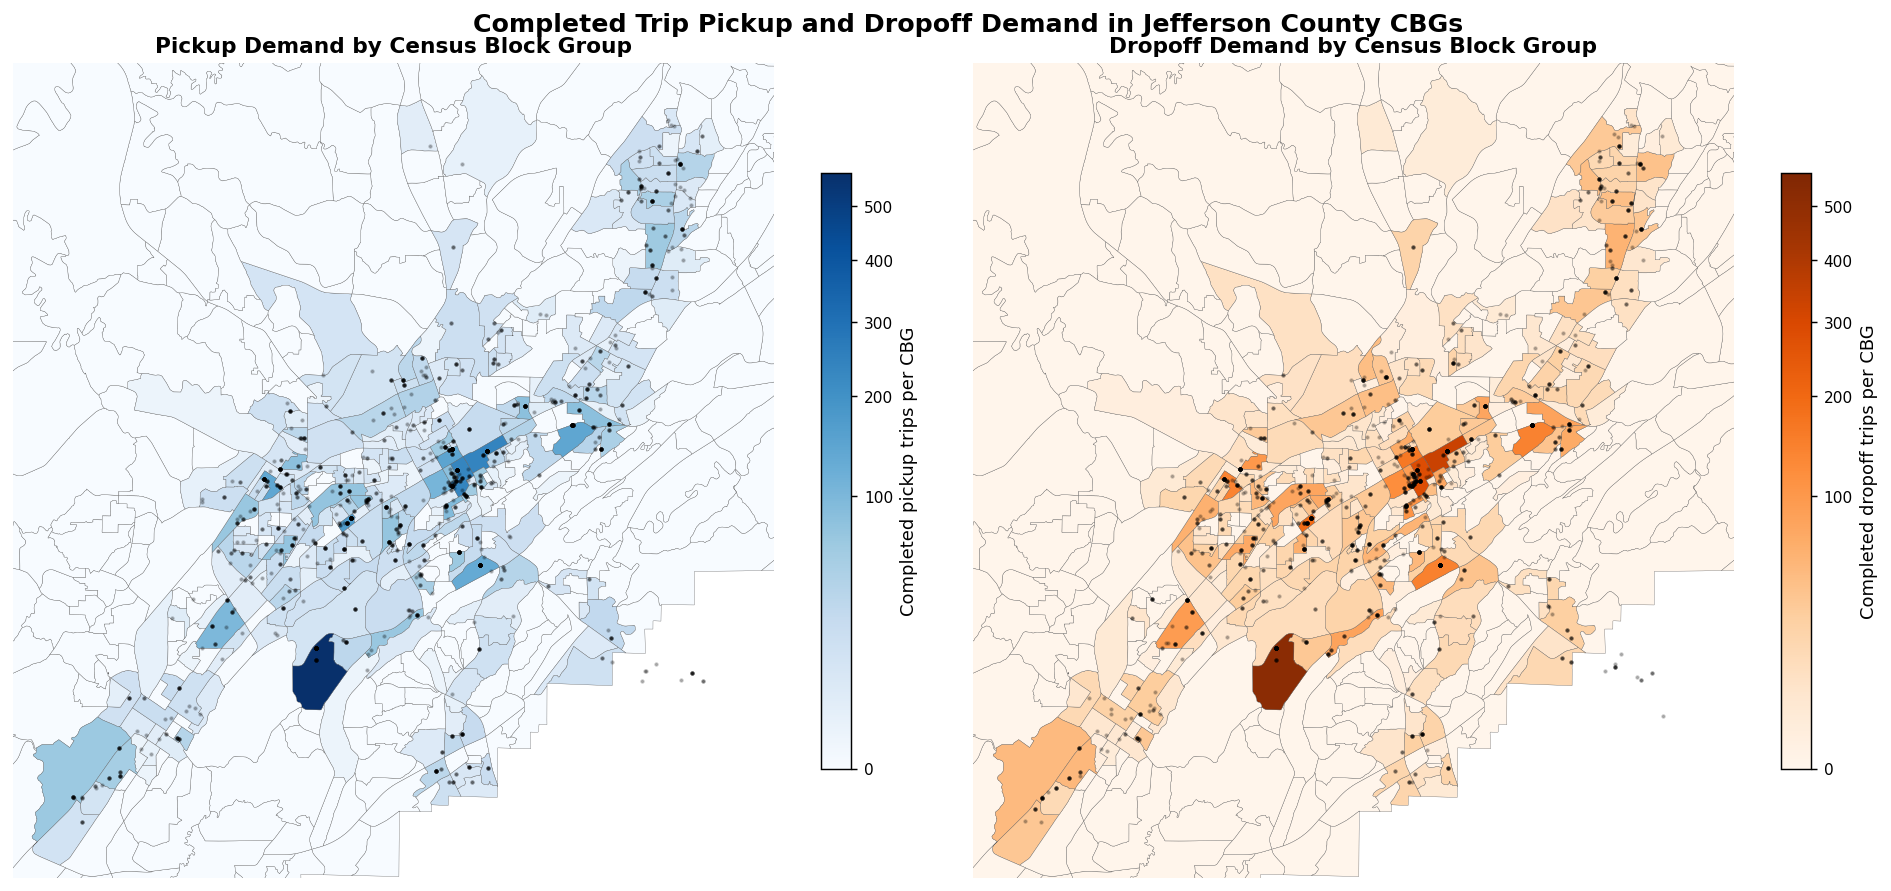

In [9]:
import geopandas as gpd

BG_PATH = Path("/scratch/umni5/a/li5125/DOE_analysis/RFI-Rider_flexibility_index-/tl_2021_01_bg/tl_2021_01_bg.shp")

# Load Jefferson County block group polygons and attach the CBG attributes.
cbg_poly = gpd.read_file(BG_PATH)
cbg_poly = cbg_poly[(cbg_poly['STATEFP'] == '01') & (cbg_poly['COUNTYFP'] == '073')].copy()

df_cbg = df_cbg.copy()
df_cbg['GEOID'] = (
    df_cbg['state'].astype(int).astype(str).str.zfill(2)
    + df_cbg['county'].astype(int).astype(str).str.zfill(3)
    + df_cbg['tract'].astype(int).astype(str).str.zfill(6)
    + df_cbg['block group'].astype(int).astype(str).str.zfill(1)
)
cbg_poly = cbg_poly.merge(df_cbg, on='GEOID', how='left')

# Spatially mark each trip's pickup and dropoff block group.
pickup_points = gpd.GeoDataFrame(
    df_clean[['pickup_lon', 'pickup_lat']].copy(),
    geometry=gpd.points_from_xy(df_clean['pickup_lon'], df_clean['pickup_lat']),
    crs='EPSG:4326',
).to_crs(cbg_poly.crs)
pickup_points['trip_index'] = df_clean.index

dropoff_points = gpd.GeoDataFrame(
    df_clean[['dropoff_lon', 'dropoff_lat']].copy(),
    geometry=gpd.points_from_xy(df_clean['dropoff_lon'], df_clean['dropoff_lat']),
    crs='EPSG:4326',
).to_crs(cbg_poly.crs)
dropoff_points['trip_index'] = df_clean.index

pickup_join = gpd.sjoin(pickup_points, cbg_poly[['GEOID', 'geometry']], how='left', predicate='within')
dropoff_join = gpd.sjoin(dropoff_points, cbg_poly[['GEOID', 'geometry']], how='left', predicate='within')

pickup_lookup = pickup_join.dropna(subset=['GEOID']).drop_duplicates('trip_index').set_index('trip_index')['GEOID']
dropoff_lookup = dropoff_join.dropna(subset=['GEOID']).drop_duplicates('trip_index').set_index('trip_index')['GEOID']
df_clean['pickup_bg_geoid'] = df_clean.index.map(pickup_lookup)
df_clean['dropoff_bg_geoid'] = df_clean.index.map(dropoff_lookup)

pickup_blocks = set(df_clean['pickup_bg_geoid'].dropna())
dropoff_blocks = set(df_clean['dropoff_bg_geoid'].dropna())

pickup_counts = df_clean['pickup_bg_geoid'].value_counts()
dropoff_counts = df_clean['dropoff_bg_geoid'].value_counts()
cbg_poly['pickup_trip_count'] = cbg_poly['GEOID'].map(pickup_counts).fillna(0).astype(int)
cbg_poly['dropoff_trip_count'] = cbg_poly['GEOID'].map(dropoff_counts).fillna(0).astype(int)

print(f"Pickup points mapped to CBGs: {df_clean['pickup_bg_geoid'].notna().sum():,} / {len(df_clean):,}")
print(f"Dropoff points mapped to CBGs: {df_clean['dropoff_bg_geoid'].notna().sum():,} / {len(df_clean):,}")
print(f"Pickup blocks: {len(pickup_blocks):,}; dropoff blocks: {len(dropoff_blocks):,}; overlap: {len(pickup_blocks & dropoff_blocks):,}")

from matplotlib.colors import PowerNorm

vmax = max(cbg_poly['pickup_trip_count'].max(), cbg_poly['dropoff_trip_count'].max())
norm = PowerNorm(gamma=0.45, vmin=0, vmax=vmax)
pickup_plot = pickup_points.sample(min(1500, len(pickup_points)), random_state=42)
dropoff_plot = dropoff_points.sample(min(1500, len(dropoff_points)), random_state=42)

minx, miny, maxx, maxy = pickup_points.total_bounds
dx = (maxx - minx) * 0.08
dy = (maxy - miny) * 0.08

fig, axes = plt.subplots(1, 2, figsize=(15, 7), sharex=True, sharey=True)

cbg_poly.plot(
    ax=axes[0], column='pickup_trip_count', cmap='Blues', norm=norm,
    edgecolor='#555555', linewidth=0.18, legend=True,
    legend_kwds={'label': 'Completed pickup trips per CBG', 'shrink': 0.72},
)
pickup_plot.plot(ax=axes[0], markersize=2.0, color='black', alpha=0.22)
axes[0].set_title('Pickup Demand by Census Block Group')

cbg_poly.plot(
    ax=axes[1], column='dropoff_trip_count', cmap='Oranges', norm=norm,
    edgecolor='#555555', linewidth=0.18, legend=True,
    legend_kwds={'label': 'Completed dropoff trips per CBG', 'shrink': 0.72},
)
dropoff_plot.plot(ax=axes[1], markersize=2.0, color='black', alpha=0.22)
axes[1].set_title('Dropoff Demand by Census Block Group')

for ax in axes:
    ax.set_xlim(minx - dx, maxx + dx)
    ax.set_ylim(miny - dy, maxy + dy)
    ax.set_axis_off()

fig.suptitle('Completed Trip Pickup and Dropoff Demand in Jefferson County CBGs', y=0.98, fontsize=14, fontweight='bold')
plt.tight_layout()


# 5. Purpose analysis

Number of purposes: 6
Trips by purpose:
Purpose
Dialysis    1425
General     1387
Medical      726
Other        926
School       774
Work        1619

Earliest pickup hour distribution by purpose:


pickup_hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
Purpose,,,,,,,,,,,,,,,,,,,,,
Dialysis,0,0,0,0,230,201,4,20,93,167,...,68,157,55,16,2,0,0,0,0,0
General,0,0,0,0,34,16,99,148,109,91,...,131,226,71,26,15,28,7,1,0,0
Medical,0,0,0,0,12,15,49,69,55,52,...,52,71,48,12,6,4,0,0,0,0
Other,0,0,0,0,5,9,47,88,83,90,...,79,118,56,20,8,30,11,2,0,0
School,0,0,0,0,0,0,110,198,47,22,...,210,120,2,3,0,3,0,0,0,0
Work,0,0,0,0,70,132,317,99,104,51,...,133,165,257,70,26,54,6,1,0,0


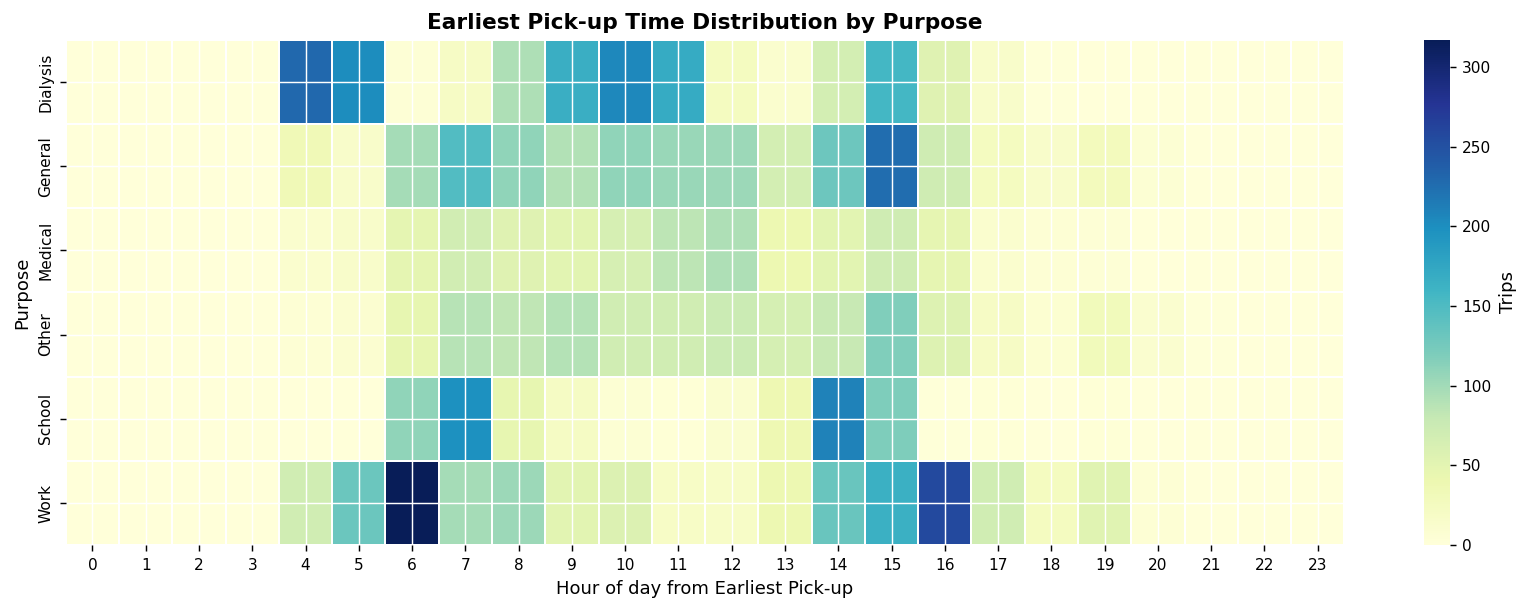

In [11]:
demands_by_purpose = {
    purpose: group.copy()
    for purpose, group in df_clean.groupby('Purpose', sort=True)
}

purpose_trip_counts = df_clean['Purpose'].value_counts().sort_index()

print(f"Number of purposes: {purpose_trip_counts.shape[0]:,}")
print("Trips by purpose:")
print(purpose_trip_counts.to_string())

def hour_from_time(s):
    if pd.isna(s):
        return np.nan
    s = str(s).strip()
    if not s:
        return np.nan
    try:
        return int(s.split(':')[0])
    except Exception:
        dt = pd.to_datetime(s, errors='coerce')
        return np.nan if pd.isna(dt) else dt.hour

df_purpose_time = df_clean.copy()
df_purpose_time['pickup_hour'] = df_purpose_time['Earliest Pick-up'].apply(hour_from_time)

purpose_pickup_hour_distribution = (
    df_purpose_time
    .dropna(subset=['pickup_hour'])
    .assign(pickup_hour=lambda x: x['pickup_hour'].astype(int))
    .groupby(['Purpose', 'pickup_hour'])
    .size()
    .unstack(fill_value=0)
    .reindex(index=purpose_trip_counts.index)
    .reindex(columns=range(24), fill_value=0)
)

print("\nEarliest pickup hour distribution by purpose:")
display(purpose_pickup_hour_distribution)

fig, ax = plt.subplots(figsize=(13, 4.8))
sns.heatmap(
    purpose_pickup_hour_distribution,
    ax=ax,
    cmap='YlGnBu',
    linewidths=0.25,
    linecolor='white',
    cbar_kws={'label': 'Trips'},
)
ax.set_xlabel('Hour of day from Earliest Pick-up')
ax.set_ylabel('Purpose')
ax.set_title('Earliest Pick-up Time Distribution by Purpose')
plt.tight_layout()


In [15]:
top_pickup_locations = (
    df_clean
    .groupby(['pickup_address', 'pickup_lat', 'pickup_lon'])
    .agg(
        num_trips=('Trip ID', 'count'),
        num_customers=('Customer Number', 'nunique'),
    )
    .reset_index()
    .sort_values(['num_trips', 'num_customers'], ascending=False)
    .head(20)
)

top_dropoff_locations = (
    df_clean
    .groupby(['dropoff_address', 'dropoff_lat', 'dropoff_lon'])
    .agg(
        num_trips=('Trip ID', 'count'),
        num_customers=('Customer Number', 'nunique'),
    )
    .reset_index()
    .sort_values(['num_trips', 'num_customers'], ascending=False)
    .head(20)
)

top_od_pairs = (
    df_clean
    .groupby([
        'pickup_address', 'pickup_lat', 'pickup_lon',
        'dropoff_address', 'dropoff_lat', 'dropoff_lon',
    ])
    .agg(
        num_trips=('Trip ID', 'count'),
        num_customers=('Customer Number', 'nunique'),
    )
    .reset_index()
    .sort_values(['num_trips', 'num_customers'], ascending=False)
    .head(20)
)

purpose_specific_od_pairs = (
    df_clean
    .groupby([
        'Purpose',
        'pickup_address', 'pickup_lat', 'pickup_lon',
        'dropoff_address', 'dropoff_lat', 'dropoff_lon',
    ])
    .agg(
        num_trips=('Trip ID', 'count'),
        num_customers=('Customer Number', 'nunique'),
    )
    .reset_index()
    .sort_values(['Purpose', 'num_trips', 'num_customers'], ascending=[True, False, False])
)

top_purpose_od_pairs = (
    purpose_specific_od_pairs
    .groupby('Purpose', group_keys=False)
    .head(20)
    .reset_index(drop=True)
)

print('Top 20 pickup locations:')
display(top_pickup_locations)

print('Top 20 dropoff locations:')
display(top_dropoff_locations)

print('Top 20 OD pairs:')
display(top_od_pairs)

print('Top 20 OD pairs within each purpose:')
display(top_purpose_od_pairs)


Top 20 pickup locations:


,pickup_address,pickup_lat,pickup_lon,num_trips,num_customers
14,"101 Oslo Cir, 35211",33.432659,-86.874540,245,14
55,"120 Oslo Cir, 35211",33.432603,-86.874327,235,13
314,"220 34th St S, 35222",33.519743,-86.783997,211,22
542,"4000 Ridgeway Dr, 35209",33.469278,-86.787902,129,31
669,"6001 Crestwood Blvd, 35212",33.531142,-86.738915,102,7
724,"708 Cotton Ave SW, 35211",33.490035,-86.856074,88,10
397,"2630 Avenue E, 35218",33.507141,-86.901755,87,9
592,"4736 9th Ave N, 35212",33.539444,-86.764095,79,4
441,"300 22nd St S, 35233",33.511142,-86.799886,75,8
166,"1616 Oxmoor Rd, 35209",33.475003,-86.799030,66,8


Top 20 dropoff locations:


,dropoff_address,dropoff_lat,dropoff_lon,num_trips,num_customers
326,"220 34th St S, 35222",33.519743,-86.783997,303,23
14,"101 Oslo Cir, 35211",33.432659,-86.874540,242,14
59,"120 Oslo Cir, 35211",33.432603,-86.874327,210,12
560,"4000 Ridgeway Dr, 35209",33.469278,-86.787902,145,34
680,"6001 Crestwood Blvd, 35212",33.531142,-86.738915,103,7
457,"300 22nd St S, 35233",33.511142,-86.799886,84,8
409,"2630 Avenue E, 35218",33.507141,-86.901755,83,10
738,"708 Cotton Ave SW, 35211",33.490035,-86.856074,83,9
227,"1809 Avenue H, 35218",33.511695,-86.893478,81,7
604,"4736 9th Ave N, 35212",33.539444,-86.764095,77,4


Top 20 OD pairs:


,pickup_address,pickup_lat,pickup_lon,dropoff_address,dropoff_lat,dropoff_lon,num_trips,num_customers
1280,"4736 9th Ave N, 35212",33.539444,-86.764095,"101 Oslo Cir, 35211",33.432659,-86.874540,79,4
28,"101 Oslo Cir, 35211",33.432659,-86.874540,"4736 9th Ave N, 35212",33.539444,-86.764095,77,4
1445,"6004 Crestwood Blvd, 35212",33.531157,-86.738866,"1528 17th Pl SW, 35211",33.476439,-86.859704,41,2
24,"101 Oslo Cir, 35211",33.432659,-86.874540,"1556 Cleveland Ave SW, 35211",33.487791,-86.857878,39,2
310,"1556 Cleveland Ave SW, 35211",33.487791,-86.857878,"101 Oslo Cir, 35211",33.432659,-86.874540,39,2
23,"101 Oslo Cir, 35211",33.432659,-86.874540,"1321 13th St S, 35205",33.495546,-86.805594,38,2
703,"220 17th Ave SW, 35211",33.479607,-86.835695,"6004 Crestwood Blvd, 35212",33.531157,-86.738866,38,2
385,"1624 5th St NW, 35215",33.629755,-86.696695,"220 34th St S, 35222",33.519743,-86.783997,37,2
203,"1321 13th St S, 35205",33.495546,-86.805594,"101 Oslo Cir, 35211",33.432659,-86.874540,35,2
637,"2040 Highland Ave S, 35205",33.499748,-86.794975,"4000 Ridgeway Dr, 35209",33.469278,-86.787902,25,3


Top 20 OD pairs within each purpose:


,Purpose,pickup_address,pickup_lat,pickup_lon,dropoff_address,dropoff_lat,dropoff_lon,num_trips,num_customers
0,Dialysis,"708 Cotton Ave SW, 35211",33.490035,-86.856074,"2504 Avenue K, 35218",33.504619,-86.894894,14,1
1,Dialysis,"7780 Ludington Ln, 35210",33.531658,-86.719372,"2320 3rd Pl NW, 35215",33.646418,-86.693149,14,1
2,Dialysis,"1425 Montclair Rd, 35213",33.523462,-86.727030,"300 22nd St S, 35233",33.511142,-86.799886,13,1
3,Dialysis,"1557 Arthur Shores Dr SW, 35211",33.471467,-86.855528,"9540 Parkway E, 35215",33.595828,-86.694592,13,1
4,Dialysis,"1620 1st St NW, 35215",33.628773,-86.686929,"2337 1st St Ne, 35215",33.646375,-86.681810,13,1
...,...,...,...,...,...,...,...,...,...
115,Work,"5824 Court N, 35228",33.476072,-86.893088,"1915 28th Ave S, 35209",33.481138,-86.789257,20,1
116,Work,"808 Green Springs Hwy, 35209",33.460587,-86.819365,"1720 Valley Ave, 35209",33.486753,-86.797454,20,1
117,Work,"833 Sunset Dr, 35215",33.601442,-86.696691,"1800 5th Ave N, 35203",33.516884,-86.810925,20,1
118,Work,"101 Oslo Cir, 35211",33.432659,-86.874540,"5 11th Ave SW, 35211",33.483879,-86.831210,19,1


number of trips per rider
number of unique pickup locations
number of unique dropoff locations
number of unique OD pairs
dominant purpose
dominant travel time
cancellation/no-show rate


Highly regular riders:
same OD, same time, same purpose

Moderately flexible riders:
same origin but multiple destinations

Highly flexible riders:
many purposes, many destinations, wider time distribution

In [16]:
def _mode_value(s):
    vc = s.dropna().value_counts()
    return np.nan if vc.empty else vc.index[0]

def _mode_share(s):
    vc = s.dropna().value_counts()
    return np.nan if vc.empty else vc.iloc[0] / vc.sum()

customer_trips = df_clean.copy()
customer_trips['pickup_hour'] = customer_trips['Earliest Pick-up'].apply(hour_from_time)
customer_trips['pickup_location_key'] = customer_trips[['pickup_address', 'pickup_lat', 'pickup_lon']].astype(str).agg('|'.join, axis=1)
customer_trips['dropoff_location_key'] = customer_trips[['dropoff_address', 'dropoff_lat', 'dropoff_lon']].astype(str).agg('|'.join, axis=1)
customer_trips['od_pair_key'] = customer_trips['pickup_location_key'] + ' -> ' + customer_trips['dropoff_location_key']

def summarize_completed_customer(g):
    return pd.Series({
        'num_completed_trips': g['Trip ID'].count(),
        'num_unique_pickup_locations': g['pickup_location_key'].nunique(),
        'num_unique_dropoff_locations': g['dropoff_location_key'].nunique(),
        'num_unique_od_pairs': g['od_pair_key'].nunique(),
        'num_unique_purposes': g['Purpose'].nunique(),
        'num_unique_pickup_hours': g['pickup_hour'].nunique(),
        'pickup_hour_std': g['pickup_hour'].std(),
        'dominant_purpose': _mode_value(g['Purpose']),
        'dominant_purpose_share': _mode_share(g['Purpose']),
        'dominant_travel_hour': _mode_value(g['pickup_hour']),
        'dominant_travel_hour_share': _mode_share(g['pickup_hour']),
        'top_pickup_share': _mode_share(g['pickup_location_key']),
        'top_od_share': _mode_share(g['od_pair_key']),
    })

customer_pattern_metrics = (
    customer_trips
    .groupby('Customer Number')
    .apply(summarize_completed_customer)
    .reset_index()
)

raw_customer_status = (
    df_raw.assign(status_clean=df_raw['Trip Status'].astype('string').str.strip().str.lower())
    .groupby('Customer Number')
    .agg(
        total_raw_trips=('Trip ID', 'count'),
        cancelled_trips=('status_clean', lambda s: s.isin(['cancel', 'canceled', 'cancelled']).sum()),
        noshow_trips=('status_clean', lambda s: s.isin(['noshow', 'no show', 'no-show']).sum()),
    )
    .reset_index()
)
raw_customer_status['cancellation_noshow_rate'] = (
    (raw_customer_status['cancelled_trips'] + raw_customer_status['noshow_trips'])
    / raw_customer_status['total_raw_trips']
)

customer_pattern_metrics = customer_pattern_metrics.merge(
    raw_customer_status,
    on='Customer Number',
    how='left',
)

def classify_rider(row):
    if row['num_completed_trips'] < 3:
        return 'Insufficient completed trip history'
    if (
        row['top_od_share'] >= 0.75
        and row['dominant_travel_hour_share'] >= 0.60
        and row['dominant_purpose_share'] >= 0.75
    ):
        return 'Highly regular riders'
    if (
        row['top_pickup_share'] >= 0.75
        and row['num_unique_dropoff_locations'] >= 2
        and row['num_unique_od_pairs'] >= 2
    ):
        return 'Moderately flexible riders'
    if (
        row['num_unique_purposes'] >= 3
        and row['num_unique_dropoff_locations'] >= 3
        and row['num_unique_pickup_hours'] >= 4
    ):
        return 'Highly flexible riders'
    return 'Mixed / low-signal pattern'

customer_pattern_metrics['rider_pattern_type'] = customer_pattern_metrics.apply(classify_rider, axis=1)

print('Rider pattern type counts:')
print(customer_pattern_metrics['rider_pattern_type'].value_counts().to_string())

display_cols = [
    'Customer Number', 'rider_pattern_type',
    'num_completed_trips', 'num_unique_pickup_locations', 'num_unique_dropoff_locations',
    'num_unique_od_pairs', 'dominant_purpose', 'dominant_travel_hour',
    'num_unique_purposes', 'num_unique_pickup_hours', 'pickup_hour_std',
    'cancellation_noshow_rate',
]

display(
    customer_pattern_metrics[display_cols]
    .sort_values(['rider_pattern_type', 'num_completed_trips'], ascending=[True, False])
    .head(50)
)


Rider pattern type counts:
rider_pattern_type
Mixed / low-signal pattern             294
Insufficient completed trip history    127
Highly flexible riders                  57
Highly regular riders                   16
Moderately flexible riders               8


,Customer Number,rider_pattern_type,num_completed_trips,num_unique_pickup_locations,num_unique_dropoff_locations,num_unique_od_pairs,dominant_purpose,dominant_travel_hour,num_unique_purposes,num_unique_pickup_hours,pickup_hour_std,cancellation_noshow_rate
314,5007,Highly flexible riders,49,6,6,10,Work,6,4,9,4.335524,0.443102
27,1702,Highly flexible riders,45,3,3,4,Work,6,3,8,4.887833,0.231534
117,3092,Highly flexible riders,45,3,3,4,Work,13,4,8,4.993733,0.386364
135,3210,Highly flexible riders,44,12,12,18,Work,6,4,12,4.558986,0.495929
300,4749,Highly flexible riders,44,10,13,21,General,12,4,13,3.425745,0.523148
392,5906,Highly flexible riders,44,11,12,22,Dialysis,10,4,10,3.688377,0.511936
401,5988,Highly flexible riders,44,9,10,19,Dialysis,9,4,10,3.298728,0.352357
129,3183,Highly flexible riders,41,12,12,23,Other,8,4,11,4.201771,0.680827
274,415,Highly flexible riders,40,4,4,7,Work,6,3,9,5.154970,0.377858
419,6154,Highly flexible riders,40,5,4,8,Other,20,3,11,4.551064,0.521368


Flexible-purpose trips: 4,464
Purpose
Dialysis    1425
General     1387
Medical      726
Other        926

Strict-purpose trips: 2,393
Purpose
School     774
Work      1619

Dialysis trips: 1,425
Dialysis dropoff CBGs: 87

Top Dialysis dropoff POIs:
                       dropoff_address  dropoff_lat  dropoff_lon  trip_count
                  300 22nd St S, 35233    33.511142   -86.799886          84
                  2630 Avenue E, 35218    33.507141   -86.901755          83
              708 Cotton Ave SW, 35211    33.490035   -86.856074          83
                  1809 Avenue H, 35218    33.511695   -86.893478          81
728 Richard Arrington Jr Blvd S, 35233    33.506276   -86.798409          38
                1917 32nd Ave N, 35207    33.550790   -86.828527          38
              7780 Ludington Ln, 35210    33.531658   -86.719372          37
              708 Cotton Ave Sw, 35211    33.490035   -86.856074          36
                 2337 1st St Ne, 35215    33.646375   -86

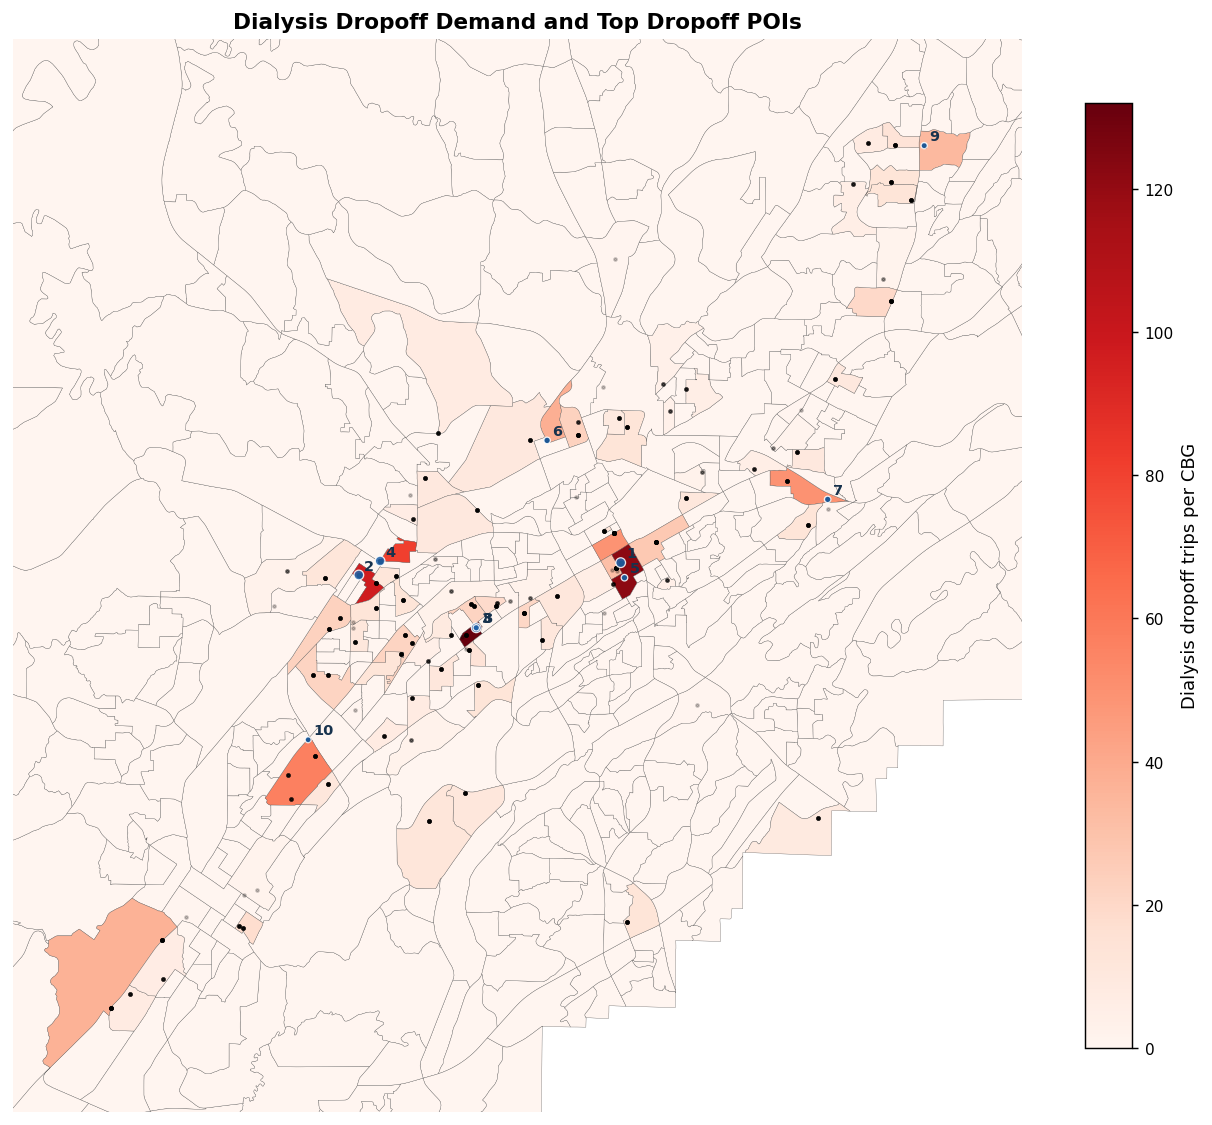

In [12]:
flexi_purposes = ['Dialysis', 'General', 'Medical', 'Other']
stri_purposes = ['School', 'Work']

df_flexi = df_clean[df_clean['Purpose'].isin(flexi_purposes)].copy()
df_stri = df_clean[df_clean['Purpose'].isin(stri_purposes)].copy()

print(f"Flexible-purpose trips: {len(df_flexi):,}")
print(df_flexi['Purpose'].value_counts().sort_index().to_string())
print(f"\nStrict-purpose trips: {len(df_stri):,}")
print(df_stri['Purpose'].value_counts().sort_index().to_string())

df_dialysis = df_clean[df_clean['Purpose'] == 'Dialysis'].copy()

dialysis_dropoff_points = gpd.GeoDataFrame(
    df_dialysis[['dropoff_address', 'dropoff_lat', 'dropoff_lon']].copy(),
    geometry=gpd.points_from_xy(df_dialysis['dropoff_lon'], df_dialysis['dropoff_lat']),
    crs='EPSG:4326',
).to_crs(cbg_poly.crs)

dialysis_dropoff_join = gpd.sjoin(
    dialysis_dropoff_points,
    cbg_poly[['GEOID', 'geometry']],
    how='left',
    predicate='within',
)
dialysis_dropoff_counts = dialysis_dropoff_join['GEOID'].value_counts()
cbg_poly['dialysis_dropoff_count'] = cbg_poly['GEOID'].map(dialysis_dropoff_counts).fillna(0).astype(int)

top_dialysis_dropoffs = (
    df_dialysis
    .groupby(['dropoff_address', 'dropoff_lat', 'dropoff_lon'])
    .size()
    .reset_index(name='trip_count')
    .sort_values('trip_count', ascending=False)
)

print(f"\nDialysis trips: {len(df_dialysis):,}")
print(f"Dialysis dropoff CBGs: {(cbg_poly['dialysis_dropoff_count'] > 0).sum():,}")
print("\nTop Dialysis dropoff POIs:")
print(top_dialysis_dropoffs.head(10).to_string(index=False))

top_pois = top_dialysis_dropoffs.head(10).copy()
top_poi_points = gpd.GeoDataFrame(
    top_pois,
    geometry=gpd.points_from_xy(top_pois['dropoff_lon'], top_pois['dropoff_lat']),
    crs='EPSG:4326',
).to_crs(cbg_poly.crs)

fig, ax = plt.subplots(figsize=(10, 10))
cbg_poly.plot(
    ax=ax,
    column='dialysis_dropoff_count',
    cmap='Reds',
    edgecolor='#555555',
    linewidth=0.18,
    legend=True,
    legend_kwds={'label': 'Dialysis dropoff trips per CBG', 'shrink': 0.75},
)
dialysis_dropoff_points.sample(min(1500, len(dialysis_dropoff_points)), random_state=42).plot(
    ax=ax,
    markersize=2.5,
    color='black',
    alpha=0.22,
)
top_poi_points.plot(
    ax=ax,
    markersize=top_poi_points['trip_count'].clip(lower=20) * 0.35,
    color='#2364AA',
    edgecolor='white',
    linewidth=0.7,
    alpha=0.88,
)

for rank, (_, row) in enumerate(top_poi_points.iterrows(), start=1):
    ax.annotate(
        str(rank),
        xy=(row.geometry.x, row.geometry.y),
        xytext=(3, 3),
        textcoords='offset points',
        fontsize=8,
        fontweight='bold',
        color='#17324D',
    )

minx, miny, maxx, maxy = dialysis_dropoff_points.total_bounds
dx = (maxx - minx) * 0.12
dy = (maxy - miny) * 0.12
ax.set_xlim(minx - dx, maxx + dx)
ax.set_ylim(miny - dy, maxy + dy)
ax.set_title('Dialysis Dropoff Demand and Top Dropoff POIs')
ax.set_axis_off()
plt.tight_layout()


Completed Dialysis trips with valid dropoff time/location: 1,425
Top Dialysis POI hourly visit distribution, using Latest Drop-off Time:


visit_hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
poi_label,,,,,,,,,,,,,,,,,,,,,
"1. 300 22nd St S, 35233 (84)",0,0,0,0,0,23,12,0,1,0,...,1,0,0,0,0,0,0,0,0,0
"2. 2630 Avenue E, 35218 (83)",0,0,0,0,0,21,25,0,9,15,...,1,0,0,0,0,0,0,0,0,0
"3. 708 Cotton Ave SW, 35211 (83)",0,0,0,0,0,27,14,1,10,12,...,0,0,0,0,0,0,0,0,0,0
"4. 1809 Avenue H, 35218 (81)",0,0,0,0,0,56,6,0,0,6,...,2,0,0,0,0,0,0,0,0,0
"5. 728 Richard Arrington Jr Blvd S, 35233 (38)",0,0,0,0,5,21,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
"6. 1917 32nd Ave N, 35207 (38)",0,0,0,0,0,13,0,0,5,16,...,0,0,0,0,0,0,0,0,0,0
"7. 7780 Ludington Ln, 35210 (37)",0,0,0,0,0,15,20,0,2,0,...,0,0,0,0,0,0,0,0,0,0
"8. 708 Cotton Ave Sw, 35211 (36)",0,0,0,0,0,36,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
"9. 2337 1st St Ne, 35215 (34)",0,0,0,0,0,21,1,0,0,11,...,0,0,0,0,0,0,0,0,0,0


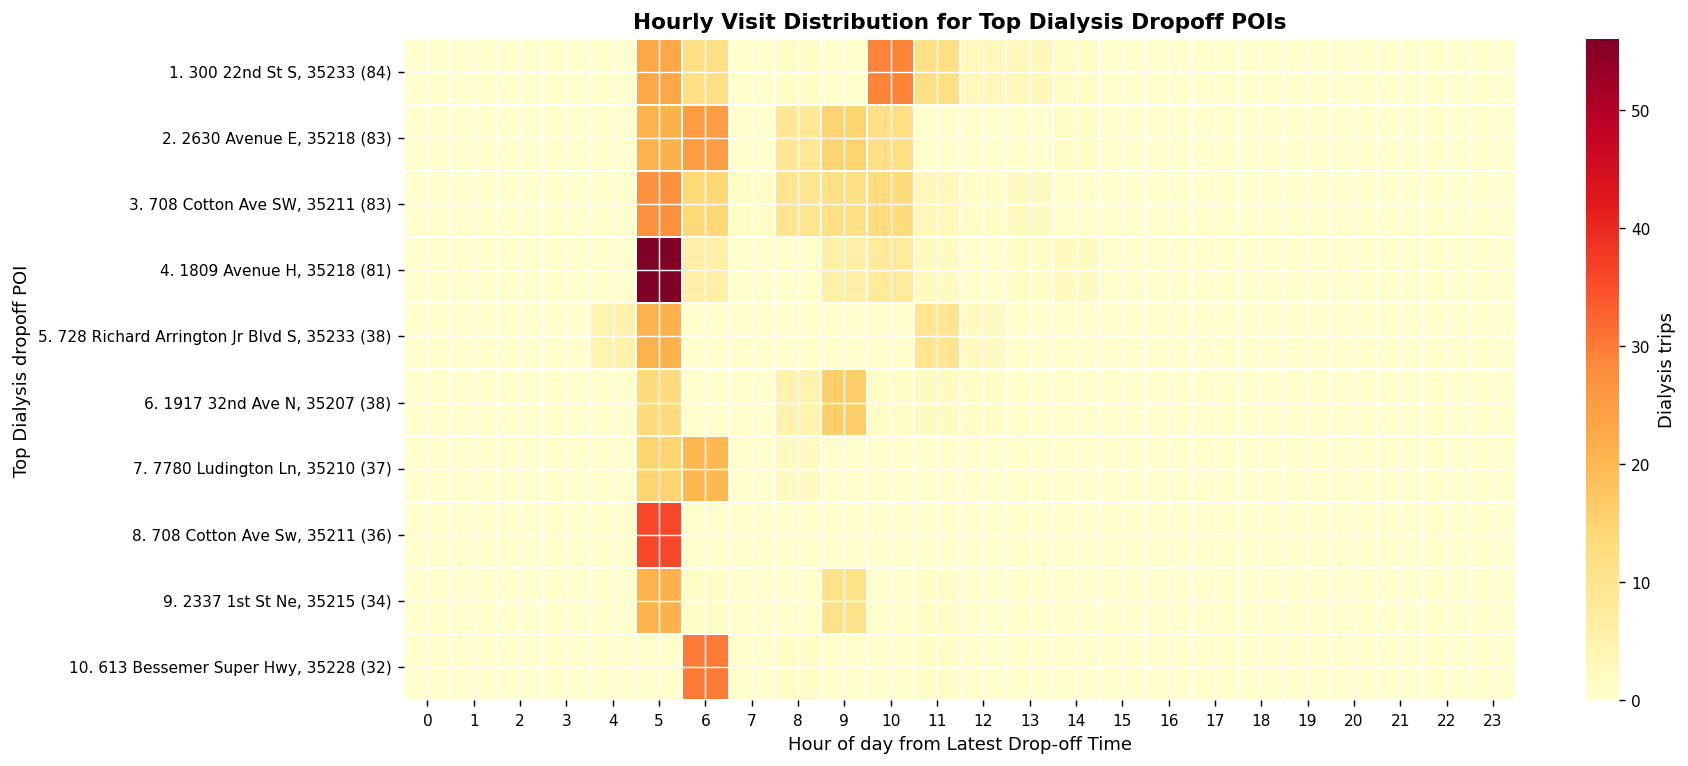

In [13]:
def hour_from_time(s):
    if pd.isna(s):
        return np.nan
    s = str(s).strip()
    if not s:
        return np.nan
    try:
        return int(s.split(':')[0])
    except Exception:
        dt = pd.to_datetime(s, errors='coerce')
        return np.nan if pd.isna(dt) else dt.hour

# Use df_clean so the hourly distribution follows the same cleaned dataset.
dropoff_time_col = 'Latest Drop-off Time'
df_dialysis_time = df_clean[df_clean['Purpose'] == 'Dialysis'].copy()
df_dialysis_time = df_dialysis_time.dropna(
    subset=['dropoff_address', 'dropoff_lat', 'dropoff_lon', dropoff_time_col]
).copy()
df_dialysis_time['visit_hour'] = df_dialysis_time['Latest Drop-off Time'].apply(hour_from_time)

top_dialysis_pois = (
    df_dialysis_time
    .groupby(['dropoff_address', 'dropoff_lat', 'dropoff_lon'])
    .size()
    .reset_index(name='trip_count')
    .sort_values('trip_count', ascending=False)
    .head(10)
    .copy()
)
top_dialysis_pois['poi_rank'] = np.arange(1, len(top_dialysis_pois) + 1)
top_dialysis_pois['poi_label'] = top_dialysis_pois.apply(
    lambda r: f"{int(r['poi_rank'])}. {r['dropoff_address']} ({int(r['trip_count'])})",
    axis=1,
)

df_dialysis_top_time = df_dialysis_time.merge(
    top_dialysis_pois[['dropoff_address', 'dropoff_lat', 'dropoff_lon', 'poi_label']],
    on=['dropoff_address', 'dropoff_lat', 'dropoff_lon'],
    how='inner',
)

dialysis_hour_distribution = (
    df_dialysis_top_time
    .dropna(subset=['visit_hour'])
    .assign(visit_hour=lambda x: x['visit_hour'].astype(int))
    .groupby(['poi_label', 'visit_hour'])
    .size()
    .unstack(fill_value=0)
    .reindex(index=top_dialysis_pois['poi_label'])
    .reindex(columns=range(24), fill_value=0)
)

print(f"Completed Dialysis trips with valid dropoff time/location: {len(df_dialysis_time):,}")
print("Top Dialysis POI hourly visit distribution, using Latest Drop-off Time:")
display(dialysis_hour_distribution)

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(
    dialysis_hour_distribution,
    ax=ax,
    cmap='YlOrRd',
    linewidths=0.25,
    linecolor='white',
    cbar_kws={'label': 'Dialysis trips'},
)
ax.set_xlabel('Hour of day from Latest Drop-off Time')
ax.set_ylabel('Top Dialysis dropoff POI')
ax.set_title('Hourly Visit Distribution for Top Dialysis Dropoff POIs')
plt.tight_layout()


In [12]:
# Dialysis trips where different customers start from the same pickup CBG
# and go to different dropoff CBGs.
# If df_clean was recreated after the map cell, rebuild the CBG labels here.
if {'pickup_bg_geoid', 'dropoff_bg_geoid'} - set(df_clean.columns):
    if 'cbg_poly' not in globals():
        BG_PATH = Path('/scratch/umni5/a/li5125/DOE_analysis/RFI-Rider_flexibility_index-/tl_2021_01_bg/tl_2021_01_bg.shp')
        cbg_poly = gpd.read_file(BG_PATH)
        cbg_poly = cbg_poly[(cbg_poly['STATEFP'] == '01') & (cbg_poly['COUNTYFP'] == '073')].copy()

    pickup_points = gpd.GeoDataFrame(
        df_clean[['pickup_lon', 'pickup_lat']].copy(),
        geometry=gpd.points_from_xy(df_clean['pickup_lon'], df_clean['pickup_lat']),
        crs='EPSG:4326',
    ).to_crs(cbg_poly.crs)
    pickup_points['trip_index'] = df_clean.index

    dropoff_points = gpd.GeoDataFrame(
        df_clean[['dropoff_lon', 'dropoff_lat']].copy(),
        geometry=gpd.points_from_xy(df_clean['dropoff_lon'], df_clean['dropoff_lat']),
        crs='EPSG:4326',
    ).to_crs(cbg_poly.crs)
    dropoff_points['trip_index'] = df_clean.index

    pickup_join = gpd.sjoin(pickup_points, cbg_poly[['GEOID', 'geometry']], how='left', predicate='within')
    dropoff_join = gpd.sjoin(dropoff_points, cbg_poly[['GEOID', 'geometry']], how='left', predicate='within')
    pickup_lookup = pickup_join.dropna(subset=['GEOID']).drop_duplicates('trip_index').set_index('trip_index')['GEOID']
    dropoff_lookup = dropoff_join.dropna(subset=['GEOID']).drop_duplicates('trip_index').set_index('trip_index')['GEOID']

    df_clean['pickup_bg_geoid'] = df_clean.index.map(pickup_lookup)
    df_clean['dropoff_bg_geoid'] = df_clean.index.map(dropoff_lookup)

dialysis_od = df_clean[df_clean['Purpose'] == 'Dialysis'].copy()
dialysis_od = dialysis_od.dropna(
    subset=['Customer Number', 'pickup_bg_geoid', 'dropoff_bg_geoid']
).copy()
dialysis_od['dropoff_hour'] = dialysis_od['Latest Drop-off Time'].apply(hour_from_time)
dialysis_od = dialysis_od.dropna(subset=['dropoff_hour']).copy()
dialysis_od['dropoff_hour'] = dialysis_od['dropoff_hour'].astype(int)

pickup_block_summary = (
    dialysis_od
    .groupby('pickup_bg_geoid')
    .agg(
        num_trips=('Trip ID', 'count'),
        num_customers=('Customer Number', 'nunique'),
        num_dropoff_blocks=('dropoff_bg_geoid', 'nunique'),
    )
    .reset_index()
)

candidate_pickup_blocks = pickup_block_summary[
    (pickup_block_summary['num_customers'] >= 2)
    & (pickup_block_summary['num_dropoff_blocks'] >= 2)
].sort_values(['num_customers', 'num_dropoff_blocks', 'num_trips'], ascending=False)

print(f"Dialysis trips with mapped pickup/dropoff CBGs: {len(dialysis_od):,}")
print(f"Pickup CBGs with >=2 customers and >=2 dropoff CBGs: {len(candidate_pickup_blocks):,}")
display(candidate_pickup_blocks.head(20))

pickup_block_hour_summary = (
    dialysis_od
    .groupby(['dropoff_hour', 'pickup_bg_geoid'])
    .agg(
        num_trips=('Trip ID', 'count'),
        num_customers=('Customer Number', 'nunique'),
        num_dropoff_blocks=('dropoff_bg_geoid', 'nunique'),
    )
    .reset_index()
)

candidate_pickup_blocks_by_hour = pickup_block_hour_summary[
    (pickup_block_hour_summary['num_customers'] >= 2)
    & (pickup_block_hour_summary['num_dropoff_blocks'] >= 2)
].sort_values(
    ['dropoff_hour', 'num_customers', 'num_dropoff_blocks', 'num_trips'],
    ascending=[True, False, False, False],
)

print("Pickup CBGs with >=2 customers and >=2 dropoff CBGs by dropoff hour:")
display(candidate_pickup_blocks_by_hour.head(50))

candidate_trips = dialysis_od[
    dialysis_od['pickup_bg_geoid'].isin(candidate_pickup_blocks['pickup_bg_geoid'])
].copy()

pickup_to_dropoff_blocks = (
    candidate_trips
    .groupby(['pickup_bg_geoid', 'dropoff_bg_geoid'])
    .agg(
        num_trips=('Trip ID', 'count'),
        num_customers=('Customer Number', 'nunique'),
        top_dropoff_address=('dropoff_address', lambda s: s.value_counts().index[0]),
    )
    .reset_index()
    .sort_values(['pickup_bg_geoid', 'num_trips'], ascending=[True, False])
)

print("Pickup CBG to different Dialysis dropoff CBG patterns:")
display(pickup_to_dropoff_blocks.head(50))


Dialysis trips with mapped pickup/dropoff CBGs: 1,425
Pickup CBGs with >=2 customers and >=2 dropoff CBGs: 22


,pickup_bg_geoid,num_trips,num_customers,num_dropoff_blocks
40,010730040003,111,14,13
47,010730045024,98,10,10
26,010730034002,98,10,8
25,010730033001,59,8,11
82,010730133002,58,6,5
21,010730027012,41,5,6
18,010730023032,53,5,5
9,010730008003,34,5,5
45,010730045021,27,5,5
19,010730024011,22,4,9


Pickup CBGs with >=2 customers and >=2 dropoff CBGs by dropoff hour:


,dropoff_hour,pickup_bg_geoid,num_trips,num_customers,num_dropoff_blocks
20,5,010730051012,25,2,2
79,9,010730052004,7,2,2
90,10,010730033001,19,2,5
88,10,010730024011,6,2,4
105,10,010730118062,19,2,2
93,10,010730040003,4,2,2
117,11,010730033001,18,5,5
125,11,010730045024,29,4,4
113,11,010730024011,5,2,5
118,11,010730034002,18,2,2


Pickup CBG to different Dialysis dropoff CBG patterns:


,pickup_bg_geoid,dropoff_bg_geoid,num_trips,num_customers,top_dropoff_address
0,010730008001,010730008003,6,1,"1917 32nd Ave N, 35207"
1,010730008001,010730015004,1,1,"1540 20th St N, 35234"
5,010730008003,010730042001,11,1,"443 Theta Ave S, 35205"
3,010730008003,010730007003,9,1,"3367 33rd St N, 35207"
2,010730008003,010730004001,5,1,"4200 46th Ave N, 35217"
4,010730008003,010730008001,5,1,"2812 34th Ave N, 35207"
6,010730008003,010730109002,4,1,"505 Bell Ct, 35217"
10,010730023032,010730118043,14,1,"2320 3rd Pl NW, 35215"
8,010730023032,010730007001,13,1,"3441 33rd Ave N, 35207"
11,010730023032,010730133002,13,1,"613 Bessemer Super Hwy, 35228"


In [18]:
# CBG-level equity and purpose-pattern analysis
age_cols = [
    'Under_5', 'Age_5_to_9', 'Age_10_to_14', 'Age_15_to_19', 'Age_20_to_24',
    'Age_25_to_34', 'Age_35_to_44', 'Age_45_to_54', 'Age_55_to_64',
    'Age_65_to_74', 'Age_75_plus',
]
education_cols = ['No_Schooling', 'High_School_Grad', 'Associates_Degree', 'Bachelors_Degree', 'Graduate_or_Professional_Degree']
income_cols = ['Income_Less_10k', 'Income_10k_15k', 'Income_15k_20k', 'Income_20k_25k', 'Income_25k_35k', 'Income_35k_50k', 'Income_50k_75k', 'Income_75k_100k', 'Income_100k_150k', 'Income_150k_200k', 'Income_200k_plus']

def ensure_cbg_geoid(frame, lon_col, lat_col, out_col):
    points = gpd.GeoDataFrame(
        frame[[lon_col, lat_col]].copy(),
        geometry=gpd.points_from_xy(frame[lon_col], frame[lat_col]),
        crs='EPSG:4326',
    ).to_crs(cbg_poly.crs)
    points['row_index'] = frame.index
    joined = gpd.sjoin(points, cbg_poly[['GEOID', 'geometry']], how='left', predicate='within')
    lookup = joined.dropna(subset=['GEOID']).drop_duplicates('row_index').set_index('row_index')['GEOID']
    frame[out_col] = frame.index.map(lookup)
    return frame

if 'cbg_poly' not in globals():
    BG_PATH = Path('/scratch/umni5/a/li5125/DOE_analysis/RFI-Rider_flexibility_index-/tl_2021_01_bg/tl_2021_01_bg.shp')
    cbg_poly = gpd.read_file(BG_PATH)
    cbg_poly = cbg_poly[(cbg_poly['STATEFP'] == '01') & (cbg_poly['COUNTYFP'] == '073')].copy()

if 'GEOID' not in df_cbg.columns:
    df_cbg = df_cbg.copy()
    df_cbg['GEOID'] = (
        df_cbg['state'].astype(int).astype(str).str.zfill(2)
        + df_cbg['county'].astype(int).astype(str).str.zfill(3)
        + df_cbg['tract'].astype(int).astype(str).str.zfill(6)
        + df_cbg['block group'].astype(int).astype(str).str.zfill(1)
    )

cbg_demo = df_cbg.copy()
# Census/ACS exports use large negative values such as -666666666 for missing estimates.
income_estimate_cols = ['Median_Household_Income', 'Mean_Household_Income']
cbg_demo[income_estimate_cols] = cbg_demo[income_estimate_cols].mask(cbg_demo[income_estimate_cols] < 0, np.nan)
cbg_demo['older_65_plus_share'] = (cbg_demo['Age_65_to_74'] + cbg_demo['Age_75_plus']) / cbg_demo['Total_Population'].replace(0, np.nan)
cbg_demo['youth_under_20_share'] = (cbg_demo['Under_5'] + cbg_demo['Age_5_to_9'] + cbg_demo['Age_10_to_14'] + cbg_demo['Age_15_to_19']) / cbg_demo['Total_Population'].replace(0, np.nan)
cbg_demo['bachelors_plus_share'] = (cbg_demo['Bachelors_Degree'] + cbg_demo['Graduate_or_Professional_Degree']) / cbg_demo['Total_Population'].replace(0, np.nan)
cbg_demo['low_income_households'] = cbg_demo[['Income_Less_10k', 'Income_10k_15k', 'Income_15k_20k', 'Income_20k_25k', 'Income_25k_35k']].sum(axis=1)
cbg_demo['income_reported_households'] = cbg_demo[income_cols].sum(axis=1)
cbg_demo['low_income_share'] = cbg_demo['low_income_households'] / cbg_demo['income_reported_households'].replace(0, np.nan)

if {'pickup_bg_geoid', 'dropoff_bg_geoid'} - set(df_clean.columns):
    df_clean = ensure_cbg_geoid(df_clean, 'pickup_lon', 'pickup_lat', 'pickup_bg_geoid')
    df_clean = ensure_cbg_geoid(df_clean, 'dropoff_lon', 'dropoff_lat', 'dropoff_bg_geoid')

# Completed service usage by pickup/dropoff CBG
pickup_usage = df_clean.groupby('pickup_bg_geoid').size().rename('completed_pickup_trips').reset_index().rename(columns={'pickup_bg_geoid': 'GEOID'})
dropoff_usage = df_clean.groupby('dropoff_bg_geoid').size().rename('completed_dropoff_trips').reset_index().rename(columns={'dropoff_bg_geoid': 'GEOID'})
cbg_usage = cbg_demo.merge(pickup_usage, on='GEOID', how='left').merge(dropoff_usage, on='GEOID', how='left')
cbg_usage[['completed_pickup_trips', 'completed_dropoff_trips']] = cbg_usage[['completed_pickup_trips', 'completed_dropoff_trips']].fillna(0)
cbg_usage['pickup_trips_per_1000_pop'] = cbg_usage['completed_pickup_trips'] / cbg_usage['Total_Population'].replace(0, np.nan) * 1000
cbg_usage['dropoff_trips_per_1000_pop'] = cbg_usage['completed_dropoff_trips'] / cbg_usage['Total_Population'].replace(0, np.nan) * 1000
cbg_usage['destination_origin_balance'] = cbg_usage['completed_dropoff_trips'] - cbg_usage['completed_pickup_trips']

print('Income level of top pickup CBGs:')
display(cbg_usage.sort_values('completed_pickup_trips', ascending=False)[[
    'GEOID', 'NAME', 'completed_pickup_trips', 'Median_Household_Income',
    'low_income_share', 'pickup_trips_per_1000_pop'
]].head(15))

print('Age composition of top pickup/dropoff CBGs:')
display(cbg_usage.sort_values('completed_pickup_trips', ascending=False)[[
    'GEOID', 'completed_pickup_trips', 'completed_dropoff_trips',
    'older_65_plus_share', 'youth_under_20_share'
]].head(15))

# Purpose relationship with pickup-CBG income, education, and age
purpose_cbg = (
    df_clean.groupby(['Purpose', 'pickup_bg_geoid'])
    .size()
    .reset_index(name='num_trips')
    .rename(columns={'pickup_bg_geoid': 'GEOID'})
    .merge(cbg_demo[['GEOID', 'Median_Household_Income', 'low_income_share', 'bachelors_plus_share', 'older_65_plus_share']], on='GEOID', how='left')
)

def weighted_mean(x, value_col):
    valid = x[[value_col, 'num_trips']].dropna()
    if valid.empty or valid['num_trips'].sum() == 0:
        return np.nan
    return np.average(valid[value_col], weights=valid['num_trips'])

purpose_demo_summary = (
    purpose_cbg.groupby('Purpose')
    .apply(lambda g: pd.Series({
        'num_trips': g['num_trips'].sum(),
        'weighted_median_income': weighted_mean(g, 'Median_Household_Income'),
        'weighted_low_income_share': weighted_mean(g, 'low_income_share'),
        'weighted_bachelors_plus_share': weighted_mean(g, 'bachelors_plus_share'),
        'weighted_older_65_plus_share': weighted_mean(g, 'older_65_plus_share'),
    }))
    .sort_values('num_trips', ascending=False)
)
print('Education/income/age relationship with trip purpose, weighted by pickup-CBG trip counts:')
display(purpose_demo_summary)

# Cancellation/no-show rate by pickup CBG from all trips with valid pickup coordinates
raw_geo_cols = ['Trip ID', 'Trip Status', 'pickup_lat', 'pickup_lon']
df_raw_geo = df_raw.dropna(subset=raw_geo_cols).copy()
df_raw_geo = ensure_cbg_geoid(df_raw_geo, 'pickup_lon', 'pickup_lat', 'pickup_bg_geoid')
df_raw_geo['status_clean'] = df_raw_geo['Trip Status'].astype('string').str.strip().str.lower()
cbg_status = (
    df_raw_geo.dropna(subset=['pickup_bg_geoid'])
    .groupby('pickup_bg_geoid')
    .agg(
        total_trips=('Trip ID', 'count'),
        cancelled_trips=('status_clean', lambda s: s.isin(['cancel', 'canceled', 'cancelled']).sum()),
        noshow_trips=('status_clean', lambda s: s.isin(['noshow', 'no show', 'no-show']).sum()),
    )
    .reset_index()
    .rename(columns={'pickup_bg_geoid': 'GEOID'})
    .merge(cbg_demo[['GEOID', 'NAME', 'Median_Household_Income', 'low_income_share', 'older_65_plus_share']], on='GEOID', how='left')
)
cbg_status['cancel_noshow_rate'] = (cbg_status['cancelled_trips'] + cbg_status['noshow_trips']) / cbg_status['total_trips']

print('Cancellation/no-show rate by pickup CBG, top 15 by trip volume:')
display(cbg_status.sort_values('total_trips', ascending=False).head(15))

income_cancel_corr = cbg_status[['Median_Household_Income', 'low_income_share', 'cancel_noshow_rate']].corr(numeric_only=True)['cancel_noshow_rate']
print('Correlation with CBG cancellation/no-show rate:')
display(income_cancel_corr)

# Question checks
dialysis_by_pickup_cbg = purpose_cbg[purpose_cbg['Purpose'] == 'Dialysis'].copy()
dialysis_older_corr = dialysis_by_pickup_cbg[['num_trips', 'older_65_plus_share']].corr(numeric_only=True).iloc[0, 1]
print(f"Dialysis pickup-CBG trip count vs older-population share correlation: {dialysis_older_corr:.3f}")

flexi_purposes = ['Dialysis', 'General', 'Medical', 'Other']
flexi_by_cbg = (
    df_clean.assign(is_flexi=df_clean['Purpose'].isin(flexi_purposes))
    .groupby('pickup_bg_geoid')
    .agg(total_completed_trips=('Trip ID', 'count'), flexi_trips=('is_flexi', 'sum'))
    .reset_index()
    .rename(columns={'pickup_bg_geoid': 'GEOID'})
    .merge(cbg_demo[['GEOID', 'NAME', 'Median_Household_Income', 'low_income_share', 'older_65_plus_share']], on='GEOID', how='left')
)
flexi_by_cbg['flexi_trip_share'] = flexi_by_cbg['flexi_trips'] / flexi_by_cbg['total_completed_trips']
print('CBGs where flexible-purpose trips are most common, minimum 20 completed trips:')
display(flexi_by_cbg[flexi_by_cbg['total_completed_trips'] >= 20].sort_values('flexi_trip_share', ascending=False).head(15))

print('CBGs mostly origins vs mostly destinations:')
display(cbg_usage.sort_values('destination_origin_balance', ascending=False)[[
    'GEOID', 'NAME', 'completed_pickup_trips', 'completed_dropoff_trips', 'destination_origin_balance'
]].head(10))
display(cbg_usage.sort_values('destination_origin_balance', ascending=True)[[
    'GEOID', 'NAME', 'completed_pickup_trips', 'completed_dropoff_trips', 'destination_origin_balance'
]].head(10))


Income level of top pickup CBGs:


,GEOID,NAME,completed_pickup_trips,Median_Household_Income,low_income_share,pickup_trips_per_1000_pop
556,010730143043,"Block Group 3, Census Tract 143.04, Jefferson ...",569.0,NaN,0.570815,614.470842
66,010730024011,"Block Group 1, Census Tract 24.01, Jefferson C...",241.0,NaN,0.694444,971.774194
138,010730045024,"Block Group 4, Census Tract 45.02, Jefferson C...",238.0,52955.0,0.529412,1004.219409
129,010730040003,"Block Group 3, Census Tract 40, Jefferson Coun...",172.0,NaN,0.596591,500.000000
74,010730027012,"Block Group 2, Census Tract 27.01, Jefferson C...",148.0,73616.0,0.000000,172.093023
65,010730023063,"Block Group 3, Census Tract 23.06, Jefferson C...",144.0,89609.0,0.413146,136.752137
102,010730034002,"Block Group 2, Census Tract 34, Jefferson Coun...",141.0,33711.0,0.551515,246.503497
249,010730107041,"Block Group 1, Census Tract 107.04, Jefferson ...",132.0,51250.0,0.518248,42.843233
137,010730045023,"Block Group 3, Census Tract 45.02, Jefferson C...",106.0,44306.0,0.607798,93.888397
498,010730133002,"Block Group 2, Census Tract 133, Jefferson Cou...",98.0,28021.0,0.684332,79.288026


Age composition of top pickup/dropoff CBGs:


,GEOID,completed_pickup_trips,completed_dropoff_trips,older_65_plus_share,youth_under_20_share
556,010730143043,569.0,519.0,0.033477,0.046436
66,010730024011,241.0,336.0,0.169355,0.000000
138,010730045024,238.0,283.0,0.101266,0.000000
129,010730040003,172.0,195.0,0.171512,0.191860
74,010730027012,148.0,165.0,0.156977,0.018605
65,010730023063,144.0,143.0,0.177588,0.009497
102,010730034002,141.0,140.0,0.159091,0.176573
249,010730107041,132.0,146.0,0.015904,0.029860
137,010730045023,106.0,121.0,0.108060,0.000000
498,010730133002,98.0,94.0,0.045307,0.134304


Education/income/age relationship with trip purpose, weighted by pickup-CBG trip counts:


...

Dialysis pickup-CBG trip count vs older-population share correlation: 0.240
CBGs where flexible-purpose trips are most common, minimum 20 completed trips:


,GEOID,total_completed_trips,flexi_trips,NAME,Median_Household_Income,low_income_share,older_65_plus_share,flexi_trip_share
256,010730141042,67,67,"Block Group 2, Census Tract 141.04, Jefferson ...",30536.0,0.500000,0.000000,1.000000
171,010730103011,40,40,"Block Group 1, Census Tract 103.01, Jefferson ...",20089.0,0.677346,0.157225,1.000000
223,010730128052,29,29,"Block Group 2, Census Tract 128.05, Jefferson ...",94358.0,0.000000,0.073733,1.000000
28,010730012004,35,35,"Block Group 4, Census Tract 12, Jefferson Coun...",NaN,0.510000,0.000000,1.000000
133,010730051012,42,42,"Block Group 2, Census Tract 51.01, Jefferson C...",13125.0,0.813397,0.000000,1.000000
106,010730040001,20,20,"Block Group 1, Census Tract 40, Jefferson Coun...",35887.0,0.503876,0.000000,1.000000
114,010730045021,83,83,"Block Group 1, Census Tract 45.02, Jefferson C...",46750.0,0.559380,0.227823,1.000000
109,010730040004,40,40,"Block Group 4, Census Tract 40, Jefferson Coun...",18160.0,0.712500,0.000000,1.000000
17,010730008003,35,35,"Block Group 3, Census Tract 8, Jefferson Count...",35134.0,0.474453,0.185693,1.000000
100,010730038023,22,22,"Block Group 3, Census Tract 38.02, Jefferson C...",44831.0,0.390449,0.035746,1.000000


CBGs mostly origins vs mostly destinations:


,GEOID,NAME,completed_pickup_trips,completed_dropoff_trips,destination_origin_balance
66,010730024011,"Block Group 1, Census Tract 24.01, Jefferson C...",241.0,336.0,95.0
138,010730045024,"Block Group 4, Census Tract 45.02, Jefferson C...",238.0,283.0,45.0
167,010730052003,"Block Group 3, Census Tract 52, Jefferson Coun...",24.0,62.0,38.0
187,010730058002,"Block Group 2, Census Tract 58, Jefferson Coun...",32.0,57.0,25.0
129,010730040003,"Block Group 3, Census Tract 40, Jefferson Coun...",172.0,195.0,23.0
527,010730141054,"Block Group 4, Census Tract 141.05, Jefferson ...",14.0,35.0,21.0
175,010730056002,"Block Group 2, Census Tract 56, Jefferson Coun...",50.0,70.0,20.0
114,010730037001,"Block Group 1, Census Tract 37, Jefferson Coun...",33.0,53.0,20.0
99,010730033001,"Block Group 1, Census Tract 33, Jefferson Coun...",83.0,101.0,18.0
74,010730027012,"Block Group 2, Census Tract 27.01, Jefferson C...",148.0,165.0,17.0


,GEOID,NAME,completed_pickup_trips,completed_dropoff_trips,destination_origin_balance
556,010730143043,"Block Group 3, Census Tract 143.04, Jefferson ...",569.0,519.0,-50.0
160,010730051032,"Block Group 2, Census Tract 51.03, Jefferson C...",73.0,35.0,-38.0
86,010730030014,"Block Group 4, Census Tract 30.01, Jefferson C...",21.0,1.0,-20.0
173,010730055002,"Block Group 2, Census Tract 55, Jefferson Coun...",20.0,1.0,-19.0
109,010730036002,"Block Group 2, Census Tract 36, Jefferson Coun...",19.0,0.0,-19.0
158,010730051012,"Block Group 2, Census Tract 51.01, Jefferson C...",42.0,24.0,-18.0
522,010730141042,"Block Group 2, Census Tract 141.04, Jefferson ...",67.0,49.0,-18.0
481,010730129192,"Block Group 2, Census Tract 129.19, Jefferson ...",17.0,0.0,-17.0
149,010730049012,"Block Group 2, Census Tract 49.01, Jefferson C...",62.0,45.0,-17.0
25,010730008005,"Block Group 5, Census Tract 8, Jefferson Count...",18.0,1.0,-17.0


RFI = w1 * temporal_flexibility
    + w2 * purpose_flexibility
    + w3 * geographical_flexibility
    - w4 * regularity_penalty

Temporal flexibility:
How spread out the rider’s trip times are.

Purpose flexibility:
Whether the purpose is strict, semi-flexible, or flexible.

Geographical flexibility:
How many alternative destinations or destination CBGs a rider uses, adjusted by distance/travel time.